In [3]:
import json
import numpy as np
import os
import cv2
import random
import pickle
from tqdm import tqdm
from enum import Enum

# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

from keras.models import Sequential, load_model
from keras.layers import BatchNormalization, Conv2D, MaxPooling2D, Activation, \
    Flatten, Dropout, Dense
from keras import backend as K
from keras.preprocessing.image import ImageDataGenerator, img_to_array
from keras.optimizers import Adam
import tensorflow as tf

from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split

Alphanum = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
            'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j',
            'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't',
            'u', 'v', 'w', 'x', 'y', 'z']


In [4]:
IMAGE_SIZE = 96
img_path = r'..\..\ImageGenerator\Targets'
json_path = r'..\..\ImageGenerator\Target Data'

In [5]:
EPOCHS = 32
INIT_LR = 1e-4
BS = 32
IMAGE_DIMS = (96, 96, 3)

WARMUP_EPOCHS = 4
SAMPLE_COUNT = len(os.listdir(img_path))
WARMUP_BATCHES = WARMUP_EPOCHS * SAMPLE_COUNT / BS

data = []
labels = []
lb = LabelBinarizer()

In [ ]:
class WarmUpLearningRateScheduler(tf.keras.callbacks.Callback):
    """Warmup learning rate scheduler
    """

    def __init__(self, warmup_batches, init_lr, verbose=0):
        """Constructor for warmup learning rate scheduler

        Arguments:
            warmup_batches {int} -- Number of batch for warmup.
            init_lr {float} -- Learning rate after warmup.

        Keyword Arguments:
            verbose {int} -- 0: quiet, 1: update messages. (default: {0})
        """

        super(WarmUpLearningRateScheduler, self).__init__()
        self.warmup_batches = warmup_batches
        self.init_lr = init_lr
        self.verbose = verbose
        self.batch_count = 0
        self.learning_rates = []

    def on_batch_end(self, batch, logs=None):
        self.batch_count = self.batch_count + 1
        lr = K.get_value(self.model.optimizer.lr)
        self.learning_rates.append(lr)

    def on_batch_begin(self, batch, logs=None):
        if self.batch_count <= self.warmup_batches:
            lr = self.batch_count*self.init_lr/self.warmup_batches
            K.set_value(self.model.optimizer.lr, lr)
            if self.verbose > 0:
                print('\nBatch %05d: WarmUpLearningRateScheduler setting learning '
                      'rate to %s.' % (self.batch_count + 1, lr))

In [ ]:
def create_training_data(image_path, json_path, img_size):
    global data
    global labels
    
    training_data = []
    training_labels = []
    
    
    for img in tqdm(os.listdir(image_path)):
        image = cv2.imread(os.path.join(image_path, img))
        image = cv2.resize(image, (img_size, img_size))
        
        # try with cv.Canny()
#         image = cv2.Canny(image, 100, 200)
        image = img_to_array(image)
        training_data.append(image)
        
        json_file = img[0:-4] + '.json'
        
        json_dict = json.load(open(os.path.join(json_path, json_file)))
        class_number = Alphanum.index(json_dict["alphanumeric"])
        training_labels.append(class_number)
        
        
    data = np.array(training_data, dtype="float") / 255.0
    labels = np.array(training_labels)
    
    print("[INFO] data matrix: {:.2f}MB".format(data.nbytes / (1024 * 1000.0)))
    
    labels = lb.fit_transform(labels)

In [ ]:
def create_model(width, height, depth, classes):
    model = Sequential()
    input_shape = (height, width, depth)
    chan_dim = -1
    if K.image_data_format == "channels_first":
        chan_dim = 1
        
    model.add(Conv2D(32, (5, 5), padding="same", input_shape=input_shape, activation="relu"))
    model.add(Dropout(0.25))

    model.add(Conv2D(64, (3, 3), padding="same", activation="relu"))
    model.add(Conv2D(128, (3, 3), padding="same", activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(256, (3, 3), padding="same", activation="relu"))
#     model.add(BatchNormalization(axis=chan_dim))
    model.add(Conv2D(512, (3, 3), padding="same", activation="relu"))
#     model.add(BatchNormalization(axis=chan_dim))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(1024, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    model.add(Dense(classes))
    model.summary()
    model.add(Activation("softmax"))
    
    return model

In [ ]:
def model_training_data():
    (xTrain, xTest, yTrain, yTest) = train_test_split(data, labels, test_size=0.2, random_state=27)
    
#     aug = ImageDataGenerator(rotation_range=25, width_shift_range=0.1, height_shift_range=0.1, \
#                              shear_range=0.2, zoom_range=0.2, fill_mode="nearest")
    
    model = create_model(96,96,3, len(lb.classes_))
    opt = Adam(lr=INIT_LR, decay=INIT_LR / EPOCHS)
    
    model.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])
    
    print("TRAINING NETWORK...")
    model.fit(xTrain, yTrain, validation_data=(xTest, yTest), steps_per_epoch=len(xTrain) // BS, \
              epochs=EPOCHS, verbose=1)
    
    print("SAVING MODEL...")
    model.save('alphanum_classifier.model')
    f = open(r"../training_data/alphanum.pickle", "wb")
    f.write(pickle.dumps(lb))
    f.close()
    print("MODEL SAVED")

In [8]:
def test_model(imagePath, loaded_model):
    image = cv2.imread(imagePath)
    
    image = cv2.resize(image, (96, 96))
#     iamge = cv2.Canny(image, 100, 200)
    image = image.astype("float") /  255.0
    image = img_to_array(image)
    image = np.expand_dims(image, axis=0)
    lb = pickle.loads(open('../training_data/alphanum.pickle', 'rb').read())
    
    print("Classifying Image...")
    prediction = loaded_model.predict(image)[0]
    idx = np.argmax(prediction)
    label = lb.classes_[idx]
    
    print("RESULT: ", end=' ')
    print(Alphanum[idx])

In [ ]:
create_training_data(img_path, json_path, 96)

In [ ]:
model_training_data()

In [6]:
model = load_model('alphanum_classifier.model')

Classifying Image...
RESULT:  1


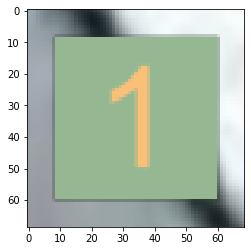

In [18]:
import matplotlib.pyplot as plt
test_flight = '../foamie_test_frames/rect.png'
gen_img = r'..\..\ImageGenerator\Targets\544.png'
test_model(gen_img, model)
img = cv2.imread(gen_img)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))